Signals and system expressions:

x1(t) = e^{-0.2t} sin(2πt)
x2(t) = cos(0.5t)

y1(t) = ∫_0^t x1(τ) dτ = ∫_0^t e^{-0.2τ} sin(2π τ) dτ

y2(t) = 0.5 x2(t) + 0.3 sin(0.5t) = 0.5 cos(0.5t) + 0.3 sin(0.5t)

y(t) = y1(t) + y2(t) = ∫_0^t e^{-0.2τ} sin(2π τ) dτ + 0.5 cos(0.5t) + 0.3 sin(0.5t)


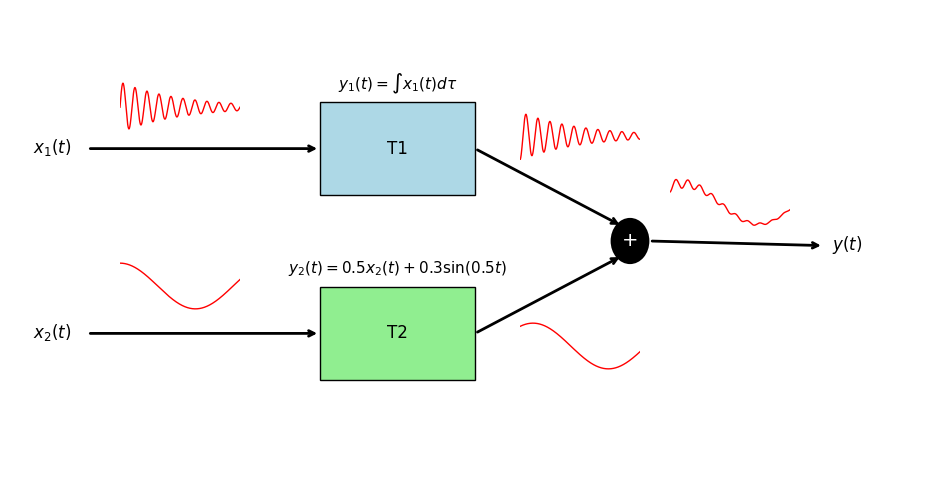

In [31]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0,10,500)
dt = t[1]-t[0]

# signals
x1 = np.exp(-0.2*t)*np.sin(2*np.pi*t)
x2 = np.cos(0.5*t)

# systems
y1 = np.cumsum(x1)*dt
y2 = 0.5*x2 + 0.3*np.sin(0.5*t)

# adder output
y = y1 + y2

fig, ax = plt.subplots(figsize=(12,6))

systems = [ (4,4,'T1',r'$y_1(t)=\int x_1(t)d\tau$','lightblue'),
            (4,2,'T2',r'$y_2(t)=0.5x_2(t)+0.3\sin(0.5t)$','lightgreen') ]

# draw system boxes
for x0,y0,label,eq,color in systems:
    ax.add_patch(plt.Rectangle((x0,y0),2,1,facecolor=color,edgecolor='black'))
    ax.text(x0+1,y0+0.5,label,ha='center',va='center',fontsize=12)
    ax.text(x0+1,y0+1.2,eq,ha='center',va='center',fontsize=11)

# input arrows
ax.annotate('',xy=(4,4.5),xytext=(1,4.5),arrowprops=dict(arrowstyle='->',lw=2))
ax.annotate('',xy=(4,2.5),xytext=(1,2.5),arrowprops=dict(arrowstyle='->',lw=2))

ax.text(0.3,4.45,r'$x_1(t)$',fontsize=12)
ax.text(0.3,2.45,r'$x_2(t)$',fontsize=12)

# arrows from systems to adder
ax.annotate('',xy=(7.9,3.66),xytext=(6,4.5),arrowprops=dict(arrowstyle='->',lw=2))
ax.annotate('',xy=(7.9,3.34),xytext=(6,2.5),arrowprops=dict(arrowstyle='->',lw=2))

# adder (circle with +)
circle = plt.Circle((8,3.5),0.25,facecolor='black')
ax.add_patch(circle)
ax.text(8,3.5,'+',color='white',ha='center',va='center',fontsize=14)

# output arrow
ax.annotate('',xy=(10.5,3.45),xytext=(8.25,3.5),arrowprops=dict(arrowstyle='->',lw=2))
ax.text(10.6,3.4,r'$y(t)$',fontsize=12)

# mini signal plots
signals = [ (3.2, x1), (3.2, x2), (7.2, y1), (7.2, y2), (8.7, y) ]

positions = [ 0.68,  # x1
              0.38,  # x2
              0.63,  # y1
              0.28,  # y2
              0.52   # y 
            ]

for (xc,sig),bottom in zip(signals,positions):
    width = 0.10
    height = 0.08
    left = xc/12 - width/2

    inset = fig.add_axes([left,bottom,width,height])
    inset.plot(t,sig,color='red',lw=1)
    inset.set_xlim(t[0],t[-1])
    inset.set_ylim(np.min(sig)*1.05,np.max(sig)*1.05)
    inset.set_xticks([])
    inset.set_yticks([])
    inset.axis('off')

ax.set_xlim(0,12)
ax.set_ylim(1,6)
ax.axis('off')

print("Signals and system expressions:\n")

print("x1(t) = e^{-0.2t} sin(2πt)")
print("x2(t) = cos(0.5t)")

print("\ny1(t) = ∫_0^t x1(τ) dτ = ∫_0^t e^{-0.2τ} sin(2π τ) dτ")

print("\ny2(t) = 0.5 x2(t) + 0.3 sin(0.5t) = 0.5 cos(0.5t) + 0.3 sin(0.5t)")

print("\ny(t) = y1(t) + y2(t) = ∫_0^t e^{-0.2τ} sin(2π τ) dτ + 0.5 cos(0.5t) + 0.3 sin(0.5t)")

plt.show()